In [40]:

import multiprocessing

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from scipy.optimize import curve_fit
from scipy.stats import norm


In [41]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.figsize": (5.8, 3.6),  # tipico per colonna singola
    "lines.linewidth": 1.2,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
})

In [42]:
# ============================================================
# CONFIGURATION
# ============================================================
FILES = {
    "50d": {
        "path": "csv-files/zro2_white&green_ 50_days.csv",
        "time": 4279386,
        "calibration": {
            "a": 0.357304,
            "b": -0.295444,
            "c": 1.352297e-9,
        },
    },
    "30d": {
        "path": "csv-files/new_data.csv",
        "time": 2827661,
        "calibration": {
            "a": 0.4142675,
            "b": 2.78,
            "c": 8.4771e-7,
        },
    },
}




# peak 3

In [43]:
ENERGY_RANGE = (0, 3000)
BIN_WIDTH = 0.4

BACKGROUND_PEAKS = {
    "228Ac_755keV" : 755.31,
    "207Tl_766keV" : 766.84,
    "152Eu_778keV" : 778.90 , 
    "228Ac_794keV" : 794.95,

}


FIT_WINDOW = 4

SIGNAL = {
    "mu": 778.2,
    "roi": (748, 810),
}

SAMPLING_CONFIG = {
    "draws": 2000,
    "tune": 2000,
    "chains": 4,
    "target_accept": 0.95,
}


In [44]:
# ============================================================
# ENERGY RESOLUTION
# ============================================================
def sigma_fun(E):
    """
    Detector energy resolution model.
    Returns sigma in keV.
    """
    A = 3.68436e1
    B = 1.72714e4

    return (E * np.sqrt(A / E + B / E**2)) / 2.355 / 100
    


In [45]:

# ============================================================
# DATA LOADING
# ============================================================
def load_spectrum(file_path, calibration, energy_range=(0, 3000)):
    """
    Load raw spectrum and convert channels to energy.
    """

    data = pd.read_csv(file_path, header=None)
    spectrum = data[0].to_numpy(dtype=np.float64)

    channels = np.arange(len(spectrum))

    E = (
        channels * calibration["a"]
        + calibration["b"]
        + calibration["c"] * channels**2
    )

    mask = (E >= energy_range[0]) & (E <= energy_range[1])

    return E[mask], spectrum[mask]

In [46]:
# ============================================================
# HISTOGRAMMING
# ============================================================
def make_histogram(E, spectrum, bins):
    counts, edges = np.histogram(E, bins=bins, weights=spectrum)
    centers = 0.5 * (edges[1:] + edges[:-1])

    return centers, counts



In [47]:

# ============================================================
# GAUSSIAN MODEL
# ============================================================
def gaussian_plus_bg(E, mu, sigma, area, m, background, ):
    """
    Gaussian normalized to total area + flat background.
    """

    gaussian = (
        area
        / (sigma * np.sqrt(2 * np.pi))
        * np.exp(-0.5 * ((E - mu) / sigma) ** 2)
    )

    return gaussian + background + m*E


In [48]:
# ============================================================
# PEAK FITTING
# ============================================================
def fit_peak(E, counts, center, window=4, plot=True):
    """
    Fit a Gaussian peak + constant background.
    """

    mask = (E > center - window) & (E < center + window)

    E_roi = E[mask]
    counts_roi = counts[mask]

    sigma_guess = sigma_fun(center)

    p0 = [
        center,
        sigma_guess,
        np.sum(counts_roi),
        0,
        np.median(counts_roi),
    ]

    bounds = (
        [center - 1, 0.01, 0, - np.inf,0],
        [center + 1, 10, np.inf, np.inf,   np.inf],
    )

    popt, pcov = curve_fit(
        gaussian_plus_bg,
        E_roi,
        counts_roi,
        p0=p0,
        bounds=bounds,
        #sigma=np.sqrt(counts_roi),
        maxfev=10000,
    )

    perr = np.sqrt(np.diag(pcov))

    result = {
        "mu": popt[0],
        "sigma": popt[1],
        "N": popt[2],
        "M" : popt[3],
        "B": popt[4],
        "err_mu": perr[0],
        "err_sigma": perr[1],
        "err_N": perr[2],
        "err_M": perr[3],
        "err_B": perr[4],
    }

    if plot:
        fig, ax = plt.subplots(
            2,
            1,
            figsize=(7, 6),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1]},
        )

        E_fit = np.linspace(E_roi.min(), E_roi.max(), 400)
        model_fit = gaussian_plus_bg(E_fit, *popt)

        ax[0].step(E_roi, counts_roi, where="mid", color="black", label="Data")
        ax[0].scatter(E_roi, counts_roi, color="black")
        ax[0].plot(E_fit, model_fit, color="red", lw=2, label="Fit")

        ax[0].set_ylabel(f"Counts / {E_roi[1]-E_roi[0]:.2f} keV")
        ax[0].set_title(f"Peak @ {center:.2f} keV")
        ax[0].legend()
        ax[0].grid(alpha=0.3)

        residuals = counts_roi - gaussian_plus_bg(E_roi, *popt)

        ax[1].scatter(E_roi, residuals, s=15)
        ax[1].axhline(0, color="red")
        ax[1].set_xlabel("Energy [keV]")
        ax[1].set_ylabel("Residuals")
        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return result


In [49]:

# ============================================================
# BUILD TOTAL DATASET
# ============================================================
def build_total_spectrum(files_config, bins):
    all_histograms = []
    total_time = 0

    for key, cfg in files_config.items():
        E, spectrum = load_spectrum(
            cfg["path"],
            cfg["calibration"],
            ENERGY_RANGE,
        )

        E_centers, counts = make_histogram(E, spectrum, bins)

        all_histograms.append(counts)
        total_time += cfg["time"]

    total_counts = np.sum(all_histograms, axis=0)

    return E_centers, total_counts, total_time

In [50]:
# ============================================================
# MAIN DATA PREPARATION
# ============================================================
BINS = np.arange(ENERGY_RANGE[0], ENERGY_RANGE[1], BIN_WIDTH)

E_tot, Ntot, t_tot = build_total_spectrum(FILES, BINS)

print(
    f"Total counts = {np.sum(Ntot):.0f} "
    f"in {t_tot / (60 * 60 * 24):.1f} days"
)


Total counts = 18324 in 82.3 days


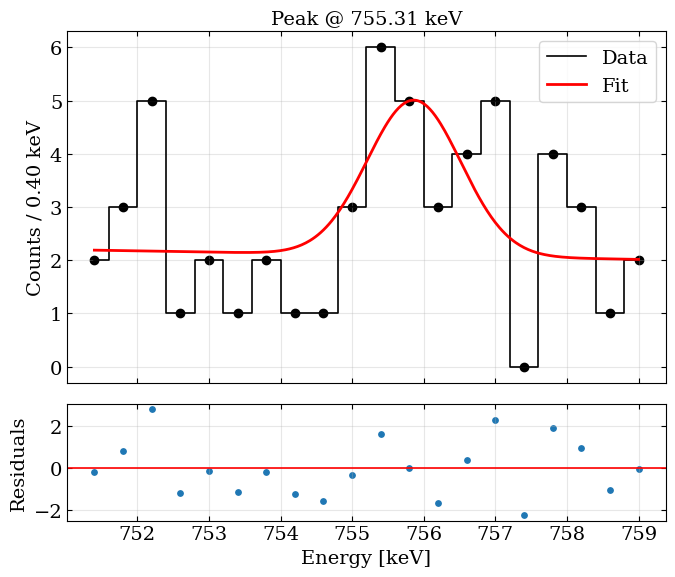

228Ac_755keV
{'mu': np.float64(755.8633918754578), 'sigma': np.float64(0.6546551468921619), 'N': np.float64(4.793534048095005), 'M': np.float64(-0.022845765586715066), 'B': np.float64(19.353935834818387), 'err_mu': np.float64(0.29959346875258525), 'err_sigma': np.float64(0.33283086074084417), 'err_N': np.float64(2.550555034841456), 'err_M': np.float64(0.1613052182471686), 'err_B': np.float64(121.73616727505821)}


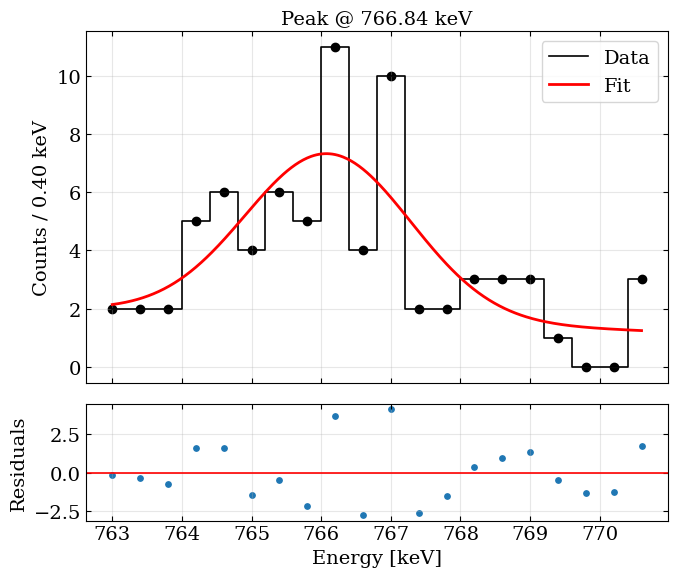

207Tl_766keV
{'mu': np.float64(766.0972434603484), 'sigma': np.float64(1.1889191511808603), 'N': np.float64(16.921634904965163), 'M': np.float64(-0.0935969448903547), 'B': np.float64(73.3606439872526), 'err_mu': np.float64(0.34579393133346426), 'err_sigma': np.float64(0.45337304129702194), 'err_N': np.float64(8.667079102017546), 'err_M': np.float64(0.29940080241564737), 'err_B': np.float64(230.18760772350757)}


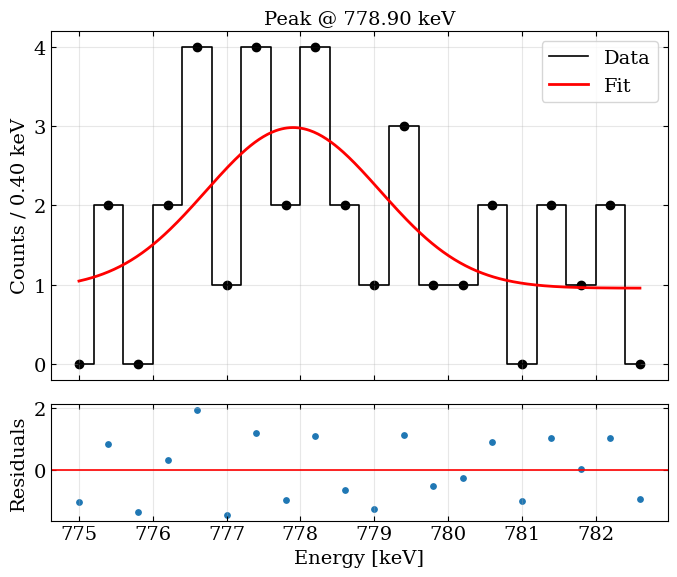

152Eu_778keV
{'mu': np.float64(777.9000000000026), 'sigma': np.float64(1.1800893770533059), 'N': np.float64(6.0186501434055035), 'M': np.float64(0.0012211151469049026), 'B': np.float64(7.127799646296351e-10), 'err_mu': np.float64(0.548794768188546), 'err_sigma': np.float64(0.7393452968985865), 'err_N': np.float64(5.252269821088473), 'err_M': np.float64(0.1862529957030897), 'err_B': np.float64(145.49311896029118)}


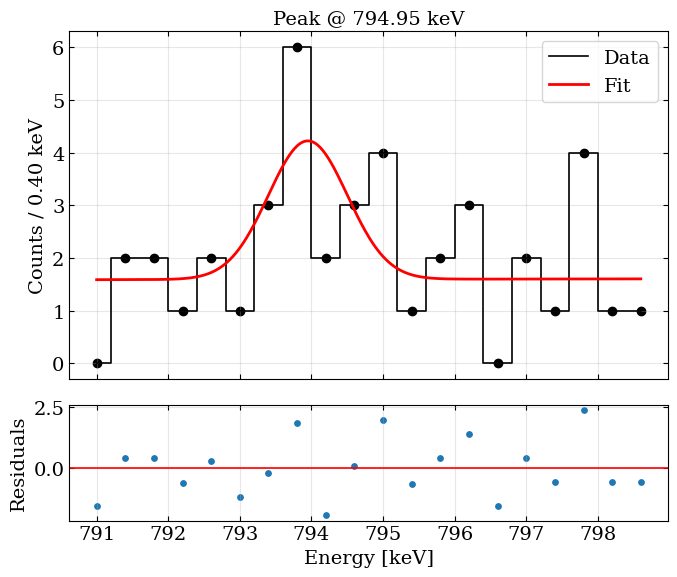

228Ac_794keV
{'mu': np.float64(793.9500000000002), 'sigma': np.float64(0.5525892919228088), 'N': np.float64(3.639762891559047), 'M': np.float64(0.002007442568683958), 'B': np.float64(8.356291515282444e-98), 'err_mu': np.float64(0.2645333030131176), 'err_sigma': np.float64(0.29004483677052484), 'err_N': np.float64(1.9485898779094124), 'err_M': np.float64(0.1405928834747691), 'err_B': np.float64(111.81325998979996)}


In [51]:
# ============================================================
# BACKGROUND PEAK FITS
# ============================================================
fit_results = {}

for peak_name, peak_energy in BACKGROUND_PEAKS.items():
    result = fit_peak(
        E_tot,
        Ntot,
        center=peak_energy,
        window=FIT_WINDOW,
        plot=True,
    )

    fit_results[peak_name] = result

    print("=" * 60)
    print(peak_name)
    print(result)

In [52]:
# ============================================================
# ROI SELECTION
# ============================================================
roi_mask = (
    (E_tot > SIGNAL["roi"][0])
    & (E_tot < SIGNAL["roi"][1])
)

E_roi = E_tot[roi_mask]
counts_roi = Ntot[roi_mask]

sigma_common = sigma_fun(E_roi.mean())
# ============================================================
# SIGNAL PDF
# ============================================================
mu_signal = SIGNAL["mu"]
sigma_signal = sigma_fun(mu_signal)

#PDF_signal = norm.pdf(E_roi, mu_signal, sigma_signal)
PDF_signal = norm.pdf(E_roi, mu_signal, sigma_common)

# ============================================================
# BACKGROUND PDFs
# ============================================================
background_names = list(BACKGROUND_PEAKS.keys())
background_energies = np.array(list(BACKGROUND_PEAKS.values()))
#background_sigmas = sigma_fun(background_energies)
background_sigmas = sigma_common
PDF_bg = np.array(
    [
        norm.pdf(E_roi, mu, sigma_common)
        for mu in background_energies
    ]
)


In [53]:

# ============================================================
# BAYESIAN MODEL
# ============================================================
with pm.Model() as model:

    # ------------------------
    # Background peak priors
    # ------------------------
    A_bg = []
    #mu_bg = []

    for peak_name in background_names:
        fit = fit_results[peak_name]

        A = pm.TruncatedNormal(
            f"A_{peak_name}",
            mu=fit["N"],
            sigma=max(fit["err_N"], 1.0),
            lower=0,
        )
        '''
        mu = pm.Normal(
        f"mu_{peak_name}",
        mu=fit["mu"],
        sigma=0.05  # o anche 0.05 keV se calibrazione buona
    )
        '''
        A_bg.append(A)
        #mu_bg.append(mu)

    A_bg = pt.stack(A_bg)
    #mu_bg = pt.stack(mu_bg)

    # ------------------------
    # Signal prior
    # ------------------------
    A_signal = pm.HalfNormal(
        "A_signal",
        sigma=500,
    )

    # ------------------------
    # Flat background prior
    # ------------------------
    Q = pm.HalfNormal(
        "Q",
        sigma=500,
    )
    

    # ------------------------
    # Expected counts
    # ------------------------
    lambda_E = (
        Q
        + pt.sum(A_bg[:, None] * PDF_bg, axis=0)
        + A_signal * PDF_signal
    )

    # Numerical stability
    lambda_E = pt.clip(lambda_E, 1e-9, np.inf)

    # ------------------------
    # Likelihood
    # ------------------------
    pm.Poisson(
        "counts_obs",
        mu=lambda_E,
        observed=counts_roi,
    )

    # ------------------------
    # Sampling
    # ------------------------
    trace = pm.sample(
        draws=SAMPLING_CONFIG["draws"],
        tune=SAMPLING_CONFIG["tune"],
        chains=SAMPLING_CONFIG["chains"],
        cores=min(4, multiprocessing.cpu_count()),
        target_accept=SAMPLING_CONFIG["target_accept"],
        init="jitter+adapt_diag",
        return_inferencedata=True,
        progressbar=True,
    )


# ============================================================
# SUMMARY
# ============================================================
summary = az.summary(trace, round_to=4)
print(summary)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A_228Ac_755keV, A_207Tl_766keV, A_152Eu_778keV, A_228Ac_794keV, A_signal, Q]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 5 seconds.


                   mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
A_228Ac_755keV   5.7611  1.6240  2.8310   8.9432     0.0215   0.0199   
A_207Tl_766keV  14.7711  2.8531  9.1981  19.9761     0.0362   0.0344   
A_152Eu_778keV   1.8423  1.4324  0.0001   4.4320     0.0179   0.0162   
A_228Ac_794keV   3.9580  1.3792  1.4752   6.6265     0.0209   0.0192   
A_signal         2.6354  1.7701  0.0004   5.7477     0.0239   0.0192   
Q                1.5083  0.1131  1.3020   1.7250     0.0015   0.0013   

                 ess_bulk   ess_tail   r_hat  
A_228Ac_755keV  5419.7854  3498.4530  1.0002  
A_207Tl_766keV  6053.3551  4738.8696  1.0001  
A_152Eu_778keV  4241.6854  2602.8256  1.0001  
A_228Ac_794keV  4078.4816  2136.5432  1.0008  
A_signal        3742.9707  2226.0079  1.0001  
Q               5458.8258  4506.9287  1.0005  


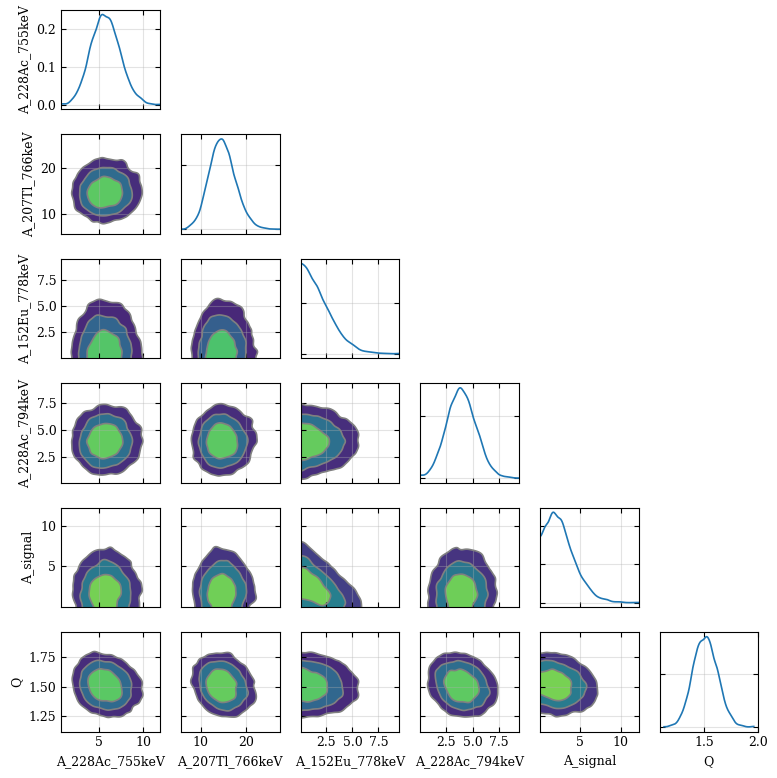

In [54]:

# ============================================================
# CORRELATION PLOTS
# ============================================================
axes = az.plot_pair(
    trace,
    kind="kde",
    marginals=True,
    figsize=(8, 8),
    textsize=9,
)

for ax in axes.flatten():
    ax.grid(alpha=0.35)

plt.tight_layout()
plt.show()


In [55]:


# ============================================================
# POSTERIOR OF SIGNAL
# ============================================================
signal_samples = trace.posterior["A_signal"].values.flatten()

N_signal_90 = np.percentile(signal_samples, 90)
N_signal_95 = np.percentile(signal_samples, 95)

print()
print("=" * 60)
print(f"90% upper limit on signal counts : {N_signal_90:.3f}")
print(f"95% upper limit on signal counts : {N_signal_95:.3f}")
print("=" * 60)


90% upper limit on signal counts : 5.085
95% upper limit on signal counts : 5.961


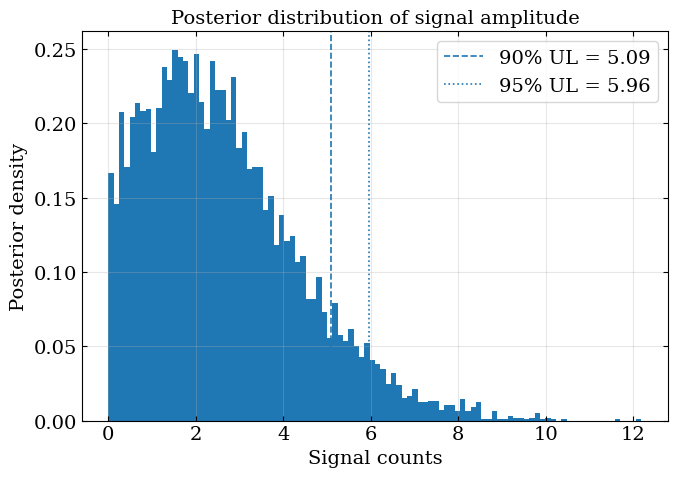

In [56]:
# ============================================================
# SIGNAL POSTERIOR PLOT
# ============================================================
plt.figure(figsize=(7, 5))

plt.hist(signal_samples, bins=100, density=True)

plt.axvline(
    N_signal_90,
    linestyle="--",
    label=f"90% UL = {N_signal_90:.2f}",
)

plt.axvline(
    N_signal_95,
    linestyle=":",
    label=f"95% UL = {N_signal_95:.2f}",
)

plt.xlabel("Signal counts")
plt.ylabel("Posterior density")
plt.title("Posterior distribution of signal amplitude")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()



In [57]:
posterior_means = {name: trace.posterior[name].mean().values for name in trace.posterior.data_vars}

print("Ampiezze medie dei picchi:")
for name, val in posterior_means.items():
    print(f"{name}: {val:.2f}")

Ampiezze medie dei picchi:
A_228Ac_755keV: 5.76
A_207Tl_766keV: 14.77
A_152Eu_778keV: 1.84
A_228Ac_794keV: 3.96
A_signal: 2.64
Q: 1.51


In [58]:
background_names = list(BACKGROUND_PEAKS.keys())
background_energies = np.array(list(BACKGROUND_PEAKS.values()))
background_sigmas = sigma_fun(background_energies)


In [59]:
idata = trace
posterior = idata.posterior

# =========================
# POSTERIOR FLATTENING
# =========================
sigma_common = sigma_fun(E_roi.mean())
Q_s        = posterior["Q"].values.flatten()
A_signal_s = posterior["A_signal"].values.flatten()

A_bg_s = {
    name: posterior[f"A_{name}"].values.flatten()
    for name in background_names
}

# =========================
# COSTRUZIONE DI λ(E) PER OGNI SAMPLE
# =========================
lambda_samples = []
lambda_back = []

for i in range(len(Q_s)):
    lam = Q_s[i] * np.ones_like(E_roi)
    lam_bkg = Q_s[i] * np.ones_like(E_roi)
    for j, name in enumerate(background_names):
        lam += A_bg_s[name][i] * PDF_bg[j]   # PDF_bg deve avere stesso ordine di background_names
        lam_bkg += A_bg_s[name][i] * PDF_bg[j]
    lam += A_signal_s[i] * PDF_signal



    lambda_samples.append(lam)
    lambda_back.append(lam_bkg)

lambda_samples = np.array(lambda_samples)
lambda_back = np.array(lambda_back)
# =========================
# STATISTICHE POSTERIORI
# =========================
lambda_mean = np.mean(lambda_samples, axis=0)
lambda_low  = np.percentile(lambda_back, 5, axis=0)
lambda_high = np.percentile(lambda_back, 95, axis=0)

# =========================
# RICOSTRUZIONE DEL SOLO BACKGROUND
# =========================
posterior_means = {
    var: posterior[var].values.mean()
    for var in posterior.data_vars
}

lambda_pred_bkg = posterior_means['Q'] * np.ones_like(E_roi) 

for j, name in enumerate(background_names):
    lambda_pred_bkg += posterior_means[f"A_{name}"] * PDF_bg[j]

# =========================
# LIMITE 90% SUL SEGNALE
# =========================
N_signal_90 = np.percentile(A_signal_s, 90)
lambda_pred = lambda_pred_bkg + N_signal_90 * PDF_signal

# =========================
# RESIDUI
# =========================
residuals = counts_roi - lambda_mean


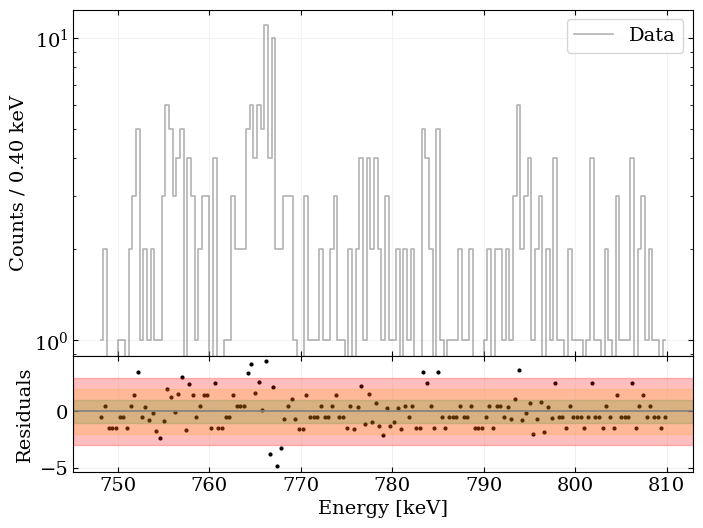

In [61]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    figsize=(8, 6)
)

# =========================
# PLOT SUPERIORE
# =========================
ax1.step(E_roi, counts_roi, where='mid', color='grey', alpha=0.6, label='Data')


#ax1.plot(E_roi, lambda_pred, color='green', lw=2, label='90% C.L. limit')
#ax1.plot(E_roi, lambda_pred_bkg, color='red', lw=2, label='Background fit')

#ax1.fill_between(E_roi, lambda_low, lambda_high,
         #        color='red', alpha=0.2, step='mid')

ax1.set_yscale('log')
ax1.set_ylabel(f"Counts / {E_roi[1]-E_roi[0]:.2f} keV")
ax1.grid(alpha=0.15)
ax1.legend()
#ax1.vlines([778.2], 1, 10)
#ax1.vlines([778.9], 1, 10)

# =========================
# PLOT INFERIORE (RESIDUI)
# =========================
ax2.scatter(E_roi, residuals, s=4, color='black')


ax2.axhspan(-3, 3, color='red', alpha=0.25)
ax2.axhspan(-2, 2, color='orange', alpha=0.2)
ax2.axhspan(-1, 1, color='green', alpha=0.15)


ax2.axhline(0, color='gray')
ax2.set_xlabel("Energy [keV]")
ax2.set_ylabel("Residuals")
ax2.grid(alpha=0.2)
plt.subplots_adjust(hspace=0)
plt.show()


# attenzione : picco anche del Eu

In [22]:

# Dati campione
m_sample = 551.3        # massa ZrO2 in grammi
Mr_sample = 123.22      # massa molare ZrO2 [g/mol]
N_A = 6.022e23          # numero di Avogadro
eff_96Zr = 0.024131  # efficienza di rivelazione
i_a_96Zr = 0.028       # abbondanza isotopica
t_live =  t_tot/(60*60*24*365)             # 50 giorni in anni

# Posterior del numero di eventi segnale
signal_samples = trace.posterior['A_signal'].values.flatten()

# Numero di nuclei 96Zr nel campione
N_nuclei = (m_sample * i_a_96Zr / Mr_sample) * N_A

percentile = 90

T_half_limit = (np.log(2) * N_nuclei * eff_96Zr * t_live) / np.percentile(signal_samples, percentile)
print(f"T1/2 > {T_half_limit:.2e} yrs at {percentile}%")

T1/2 > 5.64e+19 yrs at 90%


In [23]:
m_sample * 0.024131 * 0.001 * ( t_tot/(60*60) )

26.26334259245947

# picco centrale

In [62]:
ENERGY_RANGE = (0, 3000)
BIN_WIDTH = 0.4

BACKGROUND_PEAKS = {
    "208-Tl" :583.19,
    "208-Tl+ann" :511,
    #"EC-Sr" : 514

}


FIT_WINDOW = 5

SIGNAL = {
    "mu": 551.8,
    "roi": (551.8-50, 551.8+50),
}

SAMPLING_CONFIG = {
    "draws": 2000,
    "tune": 2000,
    "chains": 4,
    "target_accept": 0.95,
}


In [63]:
def double_gaussian_plus_bg(E, mu1, sigma1, N1, mu2, sigma2, N2, M, B):
    g1 = N1 * np.exp(-(E - mu1)**2 / (2 * sigma1**2)) / (sigma1 * np.sqrt(2*np.pi))
    g2 = N2 * np.exp(-(E - mu2)**2 / (2 * sigma2**2)) / (sigma2 * np.sqrt(2*np.pi))
    return g1 + g2 + M * E + B

In [64]:
def fit_peak(E, counts, center, window=4, plot=True):

    mask = (E > center - window) & (E < center + window)

    E_roi = E[mask]
    counts_roi = counts[mask]

    sigma_guess = sigma_fun(center)

    # ============================================================
    # CASE 1: DOUBLE PEAK REGION (505–520 keV)
    # ============================================================
    if 505 <= center <= 520:

        mu1_guess = 511.0
        mu2_guess = 514.0

        p0 = [
            mu1_guess,
            sigma_guess,
            np.sum(counts_roi) * 0.6,
            mu2_guess,
            sigma_guess,
            np.sum(counts_roi) * 0.4,
            0,
            np.median(counts_roi),
        ]

        bounds = (
            [509, 0.01, 0, 512, 0.01, 0, -np.inf, 0],
            [513, 10, np.inf, 516, 10, np.inf, np.inf, np.inf],
        )

        popt, pcov = curve_fit(
            double_gaussian_plus_bg,
            E_roi,
            counts_roi,
            p0=p0,
            bounds=bounds,
            maxfev=20000,
        )

        perr = np.sqrt(np.diag(pcov))

        result = {
            "mu1": popt[0],
            "sigma1": popt[1],
            "N1": popt[2],
            "mu2": popt[3],
            "sigma2": popt[4],
            "N2": popt[5],
            "M": popt[6],
            "B": popt[7],
        }

        model_fun = lambda x: double_gaussian_plus_bg(x, *popt)

    # ============================================================
    # CASE 2: SINGLE PEAK (DEFAULT)
    # ============================================================
    else:

        p0 = [
            center,
            sigma_guess,
            np.sum(counts_roi),
            0,
            np.median(counts_roi),
        ]

        bounds = (
            [center - 1, 0.01, 0, -np.inf, 0],
            [center + 1, 10, np.inf, np.inf, np.inf],
        )

        popt, pcov = curve_fit(
            gaussian_plus_bg,
            E_roi,
            counts_roi,
            p0=p0,
            bounds=bounds,
            maxfev=10000,
        )

        perr = np.sqrt(np.diag(pcov))

        result = {
            "mu": popt[0],
            "sigma": popt[1],
            "N": popt[2],
            "M": popt[3],
            "B": popt[4],
            "err_mu": perr[0],
            "err_sigma": perr[1],
            "err_N": perr[2],
            "err_M": perr[3],
            "err_B": perr[4],
        }

        model_fun = lambda x: gaussian_plus_bg(x, *popt)

    # ============================================================
    # PLOT (UNIFIED)
    # ============================================================

    if plot:
        fig, ax = plt.subplots(2, 1, figsize=(7, 6),
                               sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

        E_fit = np.linspace(E_roi.min(), E_roi.max(), 500)
        model_fit = model_fun(E_fit)

        ax[0].step(E_roi, counts_roi, where="mid", color="black")
        ax[0].scatter(E_roi, counts_roi, color="black", s=10)
        ax[0].plot(E_fit, model_fit, color="red", lw=2)

        ax[0].set_ylabel(f"Counts / {E_roi[1]-E_roi[0]:.2f} keV")
        ax[0].set_title(f"Peak @ {center:.2f} keV")
        ax[0].grid(alpha=0.3)

        residuals = counts_roi - model_fun(E_roi)

        ax[1].scatter(E_roi, residuals, s=15)
        ax[1].axhline(0, color="red")
        ax[1].set_xlabel("Energy [keV]")
        ax[1].set_ylabel("Residuals")
        ax[1].grid(alpha=0.3)

        plt.tight_layout()
        plt.show()

    return result

In [65]:
def build_results_double_peak(popt):
    mu1, sigma1, N1, mu2, sigma2, N2, M, B = popt

    results = {}

    # ---------------------------
    # Peak 511 (ann + Tl-208)
    # ---------------------------
    results["511_keV"] = {
        "mu": mu1,
        "sigma": sigma1,
        "N_total": N1,
        "components": {
            "annihilation + Tl-208": N1
        }
    }

    # ---------------------------
    # Peak 514 (Sr)
    # ---------------------------
    results["514_keV"] = {
        "mu": mu2,
        "sigma": sigma2,
        "N_Sr": N2
    }

    # ---------------------------
    # Background
    # ---------------------------
    results["background"] = {
        "slope": M,
        "offset": B
    }

    return results

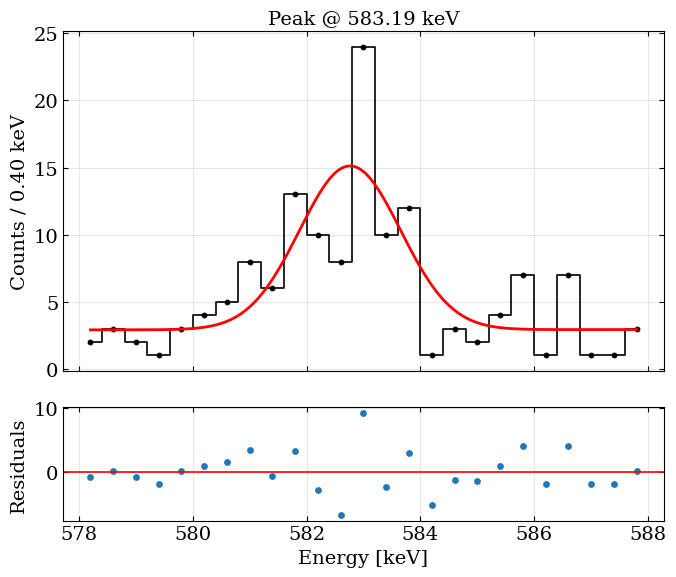

208-Tl
{'model': 'single', 'peaks': {'peak': {'mu': np.float64(582.763796158874), 'sigma': np.float64(0.8894889157166151), 'N': np.float64(27.20654698060362), 'assignment': '208-Tl'}}, 'background': {'M': np.float64(0.002238252200867003), 'B': np.float64(1.614444374692065)}}


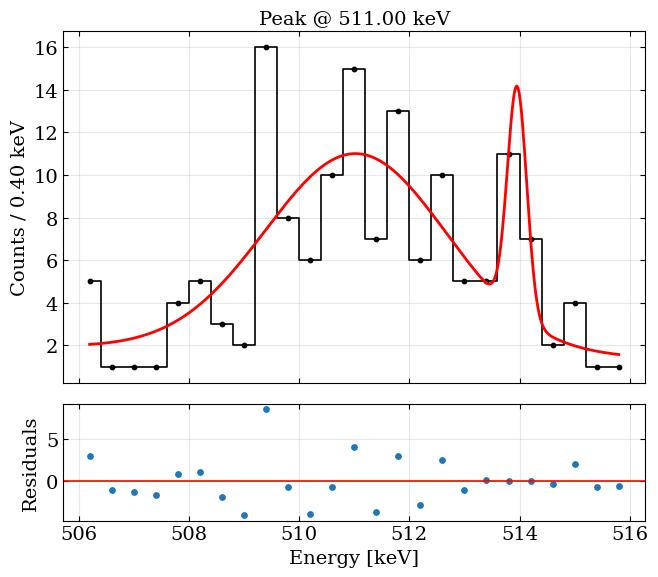

208-Tl+ann
{'model': 'double', 'peaks': {'peak1': {'mu': np.float64(511.0361454843974), 'sigma': np.float64(1.6428917283511344), 'N': np.float64(38.43915607234534), 'assignment': '511 keV (ann + Tl-208)'}, 'peak2': {'mu': np.float64(513.9557020730468), 'sigma': np.float64(0.17449979485888986), 'N': np.float64(4.692816379605403), 'assignment': '514 keV (Sr)'}}, 'background': {'M': np.float64(-0.05119903834713731), 'B': np.float64(27.835131386736062)}}


In [66]:
fit_results = {}
des = [5,5,5.5]

for (peak_name, peak_energy), de in zip(BACKGROUND_PEAKS.items(),des):

    result = fit_peak(
        E_tot,
        Ntot,
        center=peak_energy,
        window=de,
        plot=True,
    )

    # ==============================
    # WRAP OUTPUT STANDARDIZATION
    # ==============================
    if "mu1" in result:  # double gaussian case

        fit_results[peak_name] = {
            "model": "double",
            "peaks": {
                "peak1": {
                    "mu": result["mu1"],
                    "sigma": result["sigma1"],
                    "N": result["N1"],
                    "assignment": "511 keV (ann + Tl-208)"
                },
                "peak2": {
                    "mu": result["mu2"],
                    "sigma": result["sigma2"],
                    "N": result["N2"],
                    "assignment": "514 keV (Sr)"
                }
            },
            "background": {
                "M": result["M"],
                "B": result["B"],
            }
        }

    else:  # single gaussian case

        fit_results[peak_name] = {
            "model": "single",
            "peaks": {
                "peak": {
                    "mu": result["mu"],
                    "sigma": result["sigma"],
                    "N": result["N"],
                    "assignment": peak_name
                }
            },
            "background": {
                "M": result["M"],
                "B": result["B"],
            }
        }

    print("=" * 60)
    print(peak_name)
    print(fit_results[peak_name])

In [67]:
# ============================================================
# ROI SELECTION
# ============================================================
roi_mask = (
    (E_tot > SIGNAL["roi"][0])
    & (E_tot < SIGNAL["roi"][1])
)

E_roi = E_tot[roi_mask]
counts_roi = Ntot[roi_mask]

sigma_common = sigma_fun(E_roi.mean())
# ============================================================
# SIGNAL PDF
# ============================================================
mu_signal = SIGNAL["mu"]
sigma_signal = sigma_fun(mu_signal)

#PDF_signal = norm.pdf(E_roi, mu_signal, sigma_signal)
PDF_signal = norm.pdf(E_roi, mu_signal, sigma_common)

# ============================================================
# BACKGROUND PDFs
# ============================================================
background_names = list(BACKGROUND_PEAKS.keys())
background_energies = np.array(list(BACKGROUND_PEAKS.values()))
#background_sigmas = sigma_fun(background_energies)
background_sigmas = sigma_common
PDF_bg = np.array(
    [
        norm.pdf(E_roi, mu, sigma_common)
        for mu in background_energies
    ]
)


In [30]:
def get_effective_N(fit):
    if fit["model"] == "single":
        return fit["peaks"]["peak"]["N"]

    elif fit["model"] == "double":
        return (
            fit["peaks"]["peak1"]["N"] +
            fit["peaks"]["peak2"]["N"]
        )

In [31]:
with pm.Model() as model:

    # ============================================================
    # BACKGROUND PEAK PRIORS
    # ============================================================
    A_bg = []

    for peak_name in background_names:

        fit = fit_results[peak_name]

        A = pm.TruncatedNormal(
            f"A_{peak_name}",
            mu=get_effective_N(fit),
            sigma=max(
                fit["peaks"]["peak"]["sigma"] if fit["model"] == "single"
                else fit["peaks"]["peak1"]["sigma"],
                1.0
            ),
            lower=0,
        )

        A_bg.append(A)

    A_bg = pt.stack(A_bg)
    mu_bg = []

    for peak_name in background_names:

        fit = fit_results[peak_name]

        mu = pm.Normal(
            f"mu_{peak_name}",
            mu=fit["peaks"]["peak"]["mu"] if fit["model"] == "single"
            else fit["peaks"]["peak1"]["mu"],
            sigma=max(
                fit["peaks"]["peak"]["sigma"] if fit["model"] == "single"
                else fit["peaks"]["peak1"]["sigma"],
                1.0
            )
        )

        mu_bg.append(mu)

    mu_bg = pt.stack(mu_bg)


    # ============================================================
    # SIGNAL
    # ============================================================
    A_signal = pm.HalfNormal(
        "A_signal",
        sigma=500,
    )

    # ============================================================
    # FLAT BACKGROUND
    # ============================================================
    Q = pm.HalfNormal(
        "Q",
        sigma=500,
    )

    # ============================================================
    # EXPECTED COUNTS MODEL
    # ============================================================
    lambda_E = (
        Q
        + pt.sum(A_bg[:, None] * PDF_bg, axis=0)
        + A_signal * PDF_signal
    )

    lambda_E = pt.clip(lambda_E, 1e-9, np.inf)

    # ============================================================
    # LIKELIHOOD
    # ============================================================
    pm.Poisson(
        "counts_obs",
        mu=lambda_E,
        observed=counts_roi,
    )

    # ============================================================
    # SAMPLING
    # ============================================================
    trace = pm.sample(
        draws=SAMPLING_CONFIG["draws"],
        tune=SAMPLING_CONFIG["tune"],
        chains=SAMPLING_CONFIG["chains"],
        cores=min(4, multiprocessing.cpu_count()),
        target_accept=SAMPLING_CONFIG["target_accept"],
        init="jitter+adapt_diag",
        return_inferencedata=True,
        progressbar=True,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A_208-Tl, A_208-Tl+ann, A_EC-Sr, mu_208-Tl, mu_208-Tl+ann, mu_EC-Sr, A_signal, Q]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 5 seconds.


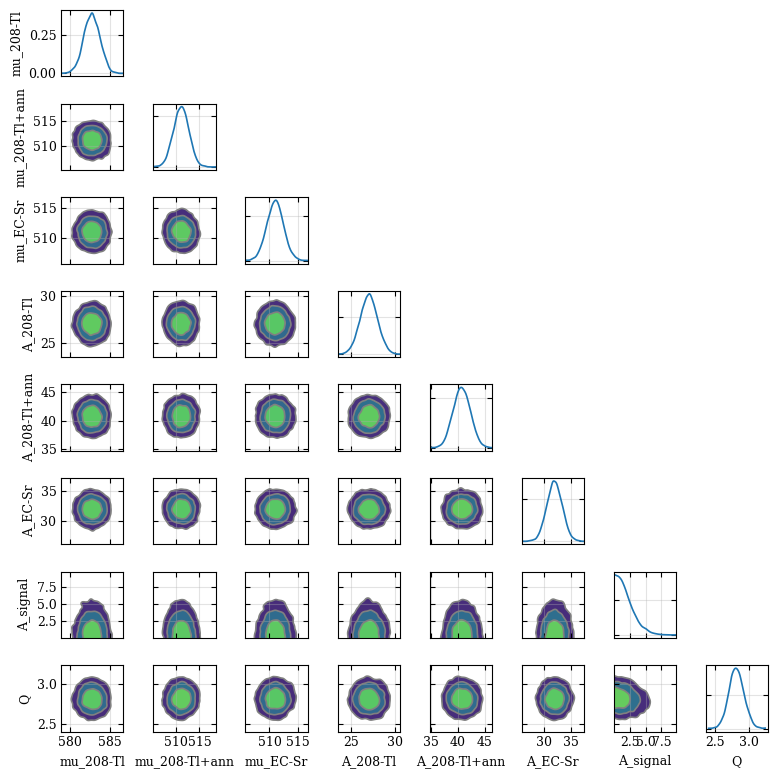

In [32]:

# ============================================================
# CORRELATION PLOTS
# ============================================================
axes = az.plot_pair(
    trace,
    kind="kde",
    marginals=True,
    figsize=(8, 8),
    textsize=9,
)

for ax in axes.flatten():
    ax.grid(alpha=0.35)

plt.tight_layout()
plt.show()


In [33]:


# ============================================================
# POSTERIOR OF SIGNAL
# ============================================================
signal_samples = trace.posterior["A_signal"].values.flatten()

N_signal_90 = np.percentile(signal_samples, 90)
N_signal_95 = np.percentile(signal_samples, 95)

print()
print("=" * 60)
print(f"90% upper limit on signal counts : {N_signal_90:.3f}")
print(f"95% upper limit on signal counts : {N_signal_95:.3f}")
print("=" * 60)


90% upper limit on signal counts : 3.763
95% upper limit on signal counts : 4.611


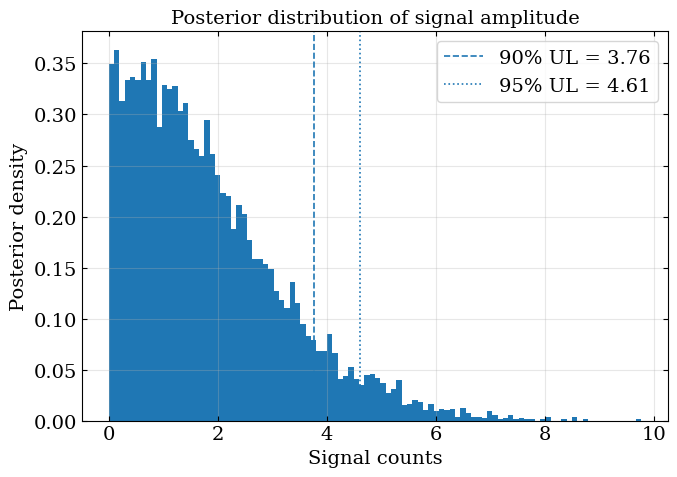

In [34]:
# ============================================================
# SIGNAL POSTERIOR PLOT
# ============================================================
plt.figure(figsize=(7, 5))

plt.hist(signal_samples, bins=100, density=True)

plt.axvline(
    N_signal_90,
    linestyle="--",
    label=f"90% UL = {N_signal_90:.2f}",
)

plt.axvline(
    N_signal_95,
    linestyle=":",
    label=f"95% UL = {N_signal_95:.2f}",
)

plt.xlabel("Signal counts")
plt.ylabel("Posterior density")
plt.title("Posterior distribution of signal amplitude")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()




In [35]:
posterior_means = {name: trace.posterior[name].mean().values for name in trace.posterior.data_vars}

print("Ampiezze medie dei picchi:")
for name, val in posterior_means.items():
    print(f"{name}: {val:.2f}")

Ampiezze medie dei picchi:
mu_208-Tl: 582.76
mu_208-Tl+ann: 511.06
mu_EC-Sr: 511.00
A_208-Tl: 27.06
A_208-Tl+ann: 40.73
A_EC-Sr: 31.93
A_signal: 1.83
Q: 2.82


In [36]:
background_names = list(BACKGROUND_PEAKS.keys())
background_energies = np.array(list(BACKGROUND_PEAKS.values()))
background_sigmas = sigma_fun(background_energies)


In [37]:
idata = trace
posterior = idata.posterior

# =========================
# POSTERIOR FLATTENING
# =========================
sigma_common = sigma_fun(E_roi.mean())
Q_s        = posterior["Q"].values.flatten()
A_signal_s = posterior["A_signal"].values.flatten()

A_bg_s = {
    name: posterior[f"A_{name}"].values.flatten()
    for name in background_names
}

# =========================
# COSTRUZIONE DI λ(E) PER OGNI SAMPLE
# =========================
lambda_samples = []
lambda_back = []

for i in range(len(Q_s)):
    lam = Q_s[i] * np.ones_like(E_roi)
    lam_bkg = Q_s[i] * np.ones_like(E_roi)
    for j, name in enumerate(background_names):
        lam += A_bg_s[name][i] * PDF_bg[j]   # PDF_bg deve avere stesso ordine di background_names
        lam_bkg += A_bg_s[name][i] * PDF_bg[j]
    lam += A_signal_s[i] * PDF_signal



    lambda_samples.append(lam)
    lambda_back.append(lam_bkg)

lambda_samples = np.array(lambda_samples)
lambda_back = np.array(lambda_back)
# =========================
# STATISTICHE POSTERIORI
# =========================
lambda_mean = np.mean(lambda_samples, axis=0)
lambda_low  = np.percentile(lambda_back, 5, axis=0)
lambda_high = np.percentile(lambda_back, 95, axis=0)

# =========================
# RICOSTRUZIONE DEL SOLO BACKGROUND
# =========================
posterior_means = {
    var: posterior[var].values.mean()
    for var in posterior.data_vars
}

lambda_pred_bkg = posterior_means['Q'] * np.ones_like(E_roi) 

for j, name in enumerate(background_names):
    lambda_pred_bkg += posterior_means[f"A_{name}"] * PDF_bg[j]

# =========================
# LIMITE 90% SUL SEGNALE
# =========================
N_signal_90 = np.percentile(A_signal_s, 90)
lambda_pred = lambda_pred_bkg + N_signal_90 * PDF_signal

# =========================
# RESIDUI
# =========================
residuals = counts_roi - lambda_mean


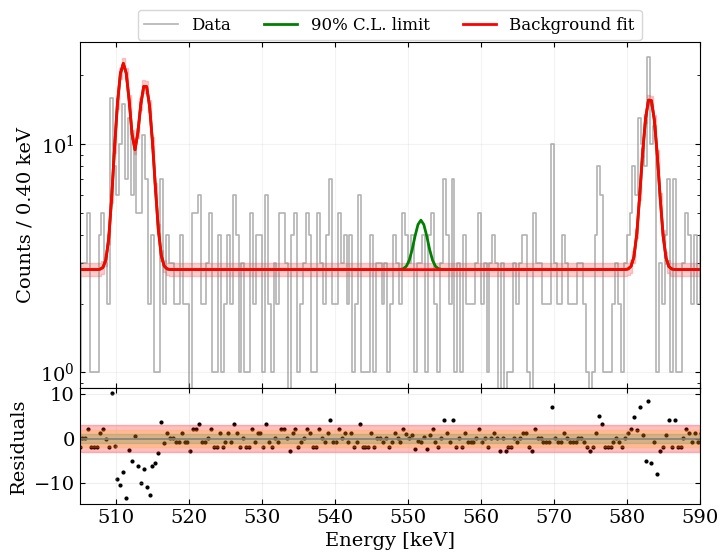

In [38]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    figsize=(8, 6)
)

# =========================
# PLOT SUPERIORE
# =========================
ax1.step(E_roi, counts_roi, where='mid', color='grey', alpha=0.6, label='Data')


ax1.plot(E_roi, lambda_pred, color='green', lw=2, label='90% C.L. limit')
ax1.plot(E_roi, lambda_pred_bkg, color='red', lw=2, label='Background fit')

ax1.fill_between(E_roi, lambda_low, lambda_high,
                 color='red', alpha=0.2, step='mid')

ax1.set_yscale('log')
ax1.set_ylabel(f"Counts / {E_roi[1]-E_roi[0]:.2f} keV")
ax1.grid(alpha=0.15)
ax1.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 0.98),
    ncol=3,
    fontsize=12
)


# =========================
# PLOT INFERIORE (RESIDUI)
# =========================
ax2.scatter(E_roi, residuals, s=4, color='black')


ax2.axhspan(-3, 3, color='red', alpha=0.25)
ax2.axhspan(-2, 2, color='orange', alpha=0.2)
ax2.axhspan(-1, 1, color='green', alpha=0.15)


ax2.axhline(0, color='gray')
ax2.set_xlabel("Energy [keV]")
ax2.set_ylabel("Residuals")
ax2.grid(alpha=0.2)
plt.xlim(505,590)
plt.subplots_adjust(hspace=0)
plt.show()
